## Import Libraries

In [ ]:

# Import libraries for data handling, visualization, model training, resampling, and evaluation.

!pip install imbalanced-learn
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

## Load Dataset

In [ ]:
# Load the BRFSS diabetes dataset

df = pd.read_csv('/content/diabetes_binary_health_indicators_BRFSS2015.csv')

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (253680, 22)
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      

## Select Relevant Features

In [ ]:
# Keep only the predictor variables and target variable that are relevant to this project.


selected_features = [
    "BMI",
    "Age",
    "HighBP",
    "HighChol",
    "CholCheck",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
    "Education",
    "Income",
    "HeartDiseaseorAttack",
    "Stroke",
    "Diabetes_binary"
]

df = df[selected_features]

print("Selected Features:")
print(df.columns.tolist())
print("New Dataset Shape:", df.shape)

Selected Features:
['BMI', 'Age', 'HighBP', 'HighChol', 'CholCheck', 'GenHlth', 'MentHlth', 'PhysHlth', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'Education', 'Income', 'HeartDiseaseorAttack', 'Stroke', 'Diabetes_binary']
New Dataset Shape: (253680, 21)


## Define Features and Traget Variables

In [ ]:
# Separate the predictor variables (X) from the target variable (y).
# Print the target distribution to examine how imbalanced the diabetes classes are.

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("Target Distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

Target Distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


## Apply SMOTE to the Training Dataset

In [ ]:
# Split the dataset into training and testing sets using stratified sampling

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64
After SMOTE: Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64


## Set Up Stratified Cross-Validation

In [ ]:
# Create a stratified 5-fold cross-validation object.
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Define Machine Learning Models and Hyperparameter Spaces

In [ ]:
# Define the machine learning models and their hyperparameter search spaces.

models = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("model", XGBClassifier(
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [4, 6, 8],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__min_child_weight": [3, 5],
            "model__gamma": [0, 0.1, 0.3]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),
        "params": {
            "model__max_depth": [5, 8, 10, 12, None],
            "model__min_samples_split": [5, 10, 20],
            "model__min_samples_leaf": [2, 4, 8],
            "model__criterion": ["gini", "entropy"]
        }
    },

    "Random Forest": {
    "pipeline": Pipeline([
        ("model", RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "params": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [10, 12, 15],
        "model__min_samples_split": [10, 20],
        "model__min_samples_leaf": [5, 10],
        "model__max_features": ["sqrt"]
    }
},
    "Gradient Boosting": {
        "pipeline": Pipeline([
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [200, 300],
            "model__learning_rate": [0.01, 0.03, 0.05],
            "model__max_depth": [3, 4],
            "model__min_samples_split": [10, 20],
            "model__min_samples_leaf": [5, 10],
            "model__subsample": [0.8]
        }
    }
}

## Train and Tune the Models

In [ ]:
# Train and tune each model with RandomizedSearchCV using stratified 5-fold cross-validation.
# Store the best version of each model and evaluate it on the test set
# using accuracy, precision, recall, F1 score, and ROC-AUC.

best_models = {}
results = []

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name} with 5-Fold Stratified Cross-Validation")
    print(f"{'='*60}")

    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=10,
        scoring="f1",
        cv=stratified_cv,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    if name == "Gradient Boosting":
        sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        search.fit(X_train, y_train, model__sample_weight=sample_weights)
    else:
        search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[name] = best_model

    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    model_result = {
        "Model": name,
        "Best Params": search.best_params_,
        "CV Mean Score": search.best_score_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    results.append(model_result)

    print("\nBest Parameters:")
    print(search.best_params_)
    print("Best CV Score:", round(search.best_score_, 4))
    print("Test Accuracy :", round(model_result["Accuracy"], 4))
    print("Test Precision:", round(model_result["Precision"], 4))
    print("Test Recall   :", round(model_result["Recall"], 4))
    print("Test F1       :", round(model_result["F1"], 4))
    print("Test ROC-AUC  :", round(model_result["ROC-AUC"], 4))


Training Logistic Regression with 5-Fold Stratified Cross-Validation
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Parameters:
{'model__C': 1}
Best CV Score: 0.4433
Test Accuracy : 0.7314
Test Precision: 0.3107
Test Recall   : 0.7609
Test F1       : 0.4412
Test ROC-AUC  : 0.8196

Training XGBoost with 5-Fold Stratified Cross-Validation
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}
Best CV Score: 0.445
Test Accuracy : 0.7392
Test Precision: 0.3155
Test Recall   : 0.7457
Test F1       : 0.4434
Test ROC-AUC  : 0.8192

Training Decision Tree with 5-Fold Stratified Cross-Validation
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 8, 'model__

## Compare Model Performance

In [ ]:
# Convert the collected model results into a DataFrame.
# Sort the models so the strongest overall performers appear first.

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["F1", "Recall", "ROC-AUC"], ascending=False)

print("MODEL COMPARISON")
print(results_df[[
    "Model",
    "CV Mean Score",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]])

MODEL COMPARISON
                 Model  CV Mean Score  Accuracy  Precision    Recall  \
3        Random Forest       0.457842  0.761057   0.332516  0.709718   
1              XGBoost       0.444988  0.739179   0.315515  0.745650   
4    Gradient Boosting       0.443757  0.721539   0.306507  0.790918   
0  Logistic Regression       0.443292  0.731433   0.310656  0.760928   
2        Decision Tree       0.430727  0.708688   0.293857  0.777479   

         F1   ROC-AUC  
3  0.452859  0.822822  
1  0.443407  0.819203  
4  0.441802  0.827101  
0  0.441191  0.819634  
2  0.426509  0.812212  


## Select the Best Model

In [ ]:
# Choose the final best-performing model for threshold tuning and detailed evaluation.

best_model_name = "XGBoost"
best_model = best_models[best_model_name]

print("Best Model Selected:", best_model_name)

Best Model Selected: XGBoost


## Tune the Classification Threshold

In [ ]:
# Generate predicted probabilities from the best model.

y_prob = best_model.predict_proba(X_test)[:, 1]

# XGBoost works better with slightly higher thresholds
thresholds = np.arange(0.50, 0.81, 0.02)

threshold_results = []
best_score = -1
best_threshold = 0.6

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    # Balanced toward F1 + precision (XGBoost strength)
    score = (0.5 * f1) + (0.3 * prec) + (0.2 * rec)

    threshold_results.append({
        "Threshold": t,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "Score": score
    })

    if score > best_score:
        best_score = score
        best_threshold = t

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values(by="Score", ascending=False)

print("Top Threshold Results:")
print(threshold_df.head(10))

print("\nBest Threshold:", best_threshold)

Top Threshold Results:
   Threshold  Accuracy  Precision    Recall        F1     Score
1       0.52  0.751636   0.325224  0.728109  0.449618  0.467998
3       0.56  0.772863   0.342055  0.682416  0.455696  0.466948
2       0.54  0.761806   0.332443  0.703919  0.451604  0.466319
4       0.58  0.782304   0.350549  0.659641  0.457808  0.465997
0       0.50  0.739179   0.315515  0.745650  0.443407  0.465488
5       0.60  0.791647   0.359673  0.634885  0.459201  0.464479
6       0.62  0.800142   0.368480  0.608573  0.459027  0.461772
7       0.64  0.808006   0.377364  0.581553  0.457719  0.458379
8       0.66  0.816186   0.388012  0.553119  0.456083  0.455069
9       0.68  0.823833   0.398896  0.521573  0.452060  0.450013

Best Threshold: 0.52


## Compute Final Performance Metrics

In [ ]:
# Use the selected optimal threshold to create final class predictions.

final_pred = (y_prob >= best_threshold).astype(int)

final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, zero_division=0)
final_recall = recall_score(y_test, final_pred, zero_division=0)
final_f1 = f1_score(y_test, final_pred, zero_division=0)
final_auc = roc_auc_score(y_test, y_prob)

print("FINAL PERFORMANCE FOR BEST MODEL")
print("Model     :", best_model_name)
print("Threshold :", round(best_threshold, 2))
print("Accuracy  :", round(final_accuracy, 4))
print("Precision :", round(final_precision, 4))
print("Recall    :", round(final_recall, 4))
print("F1 Score  :", round(final_f1, 4))
print("ROC-AUC   :", round(final_auc, 4))

FINAL PERFORMANCE FOR BEST MODEL
Model     : XGBoost
Threshold : 0.52
Accuracy  : 0.7516
Precision : 0.3252
Recall    : 0.7281
F1 Score  : 0.4496
ROC-AUC   : 0.8192


## Display Classification Report and Confusion Matrix

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.76      0.84     43667
         1.0       0.33      0.73      0.45      7069

    accuracy                           0.75     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.86      0.75      0.79     50736

Confusion Matrix:
[[32988 10679]
 [ 1922  5147]]


<Figure size 600x500 with 0 Axes>

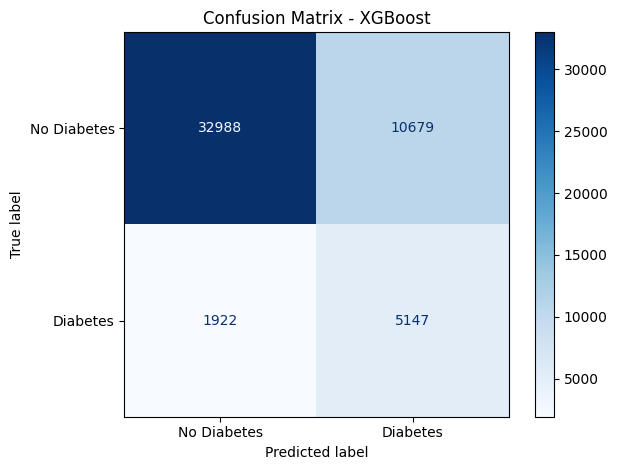

In [ ]:
# Print the detailed classification report and confusion matrix.
# Then visualize the confusion matrix to show correct and incorrect classifications clearly.

print("Classification Report:")
print(classification_report(y_test, final_pred, zero_division=0))

cm = confusion_matrix(y_test, final_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


## Plot the ROC Curve

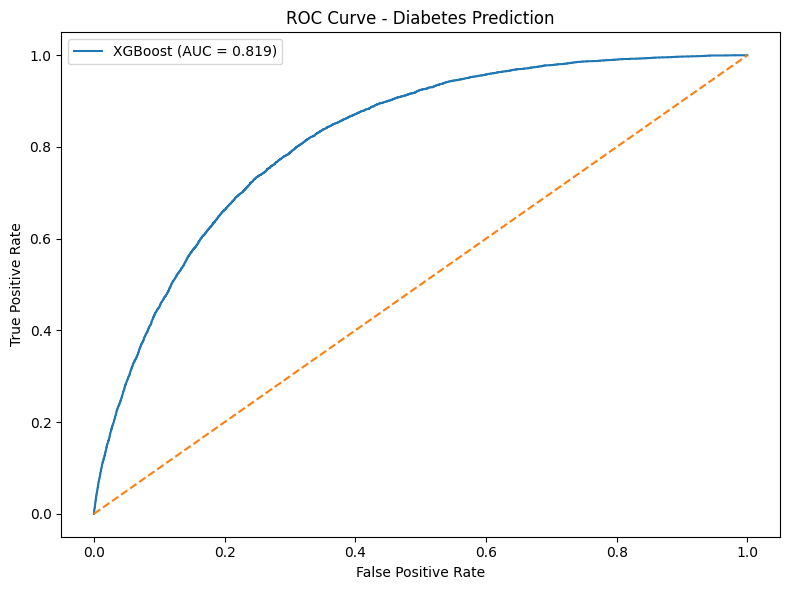

In [ ]:
# Compute the false positive rate and true positive rate for the ROC curve.
# Plot the ROC curve to visualize how well the best model separates the two classes.

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {final_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Prediction")
plt.legend()
plt.tight_layout()
plt.show()

## Plot Feature Importance

Feature Importance:
                 Feature  Importance
2                 HighBP    0.424603
5                GenHlth    0.147144
3               HighChol    0.048740
4              CholCheck    0.043532
1                    Age    0.036286
11     HvyAlcoholConsump    0.033064
0                    BMI    0.030532
18  HeartDiseaseorAttack    0.029104
15                   Sex    0.022670
14              DiffWalk    0.021652
19                Stroke    0.019669
17                Income    0.018417
6               MentHlth    0.016515
12         AnyHealthcare    0.015976
7               PhysHlth    0.015954
16             Education    0.015927
13           NoDocbcCost    0.015383
9                 Fruits    0.015273
10               Veggies    0.014990
8           PhysActivity    0.014567


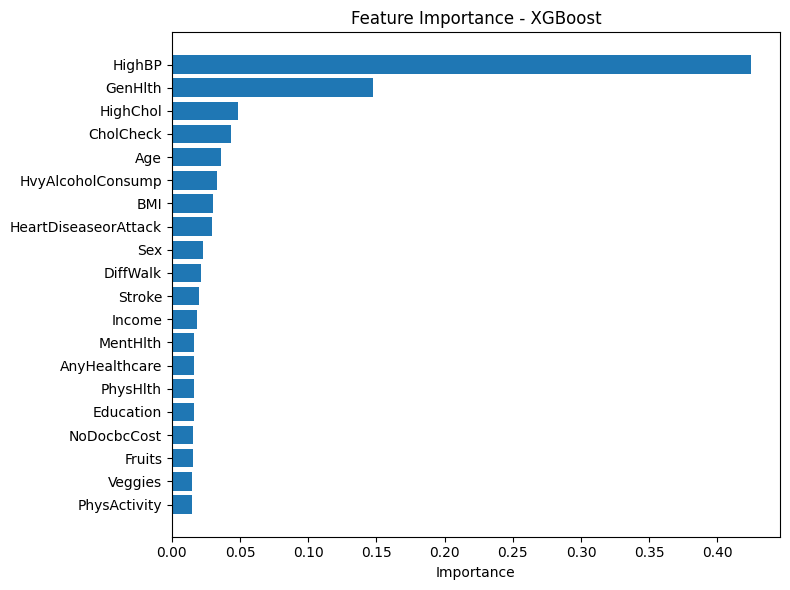

In [ ]:
# For tree-based models, extract and display feature importance values.

if best_model_name in ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"]:
    importances = best_model.named_steps["model"].feature_importances_

    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("Feature Importance:")
    print(feat_imp)

    plt.figure(figsize=(8, 6))
    plt.barh(feat_imp["Feature"][::-1], feat_imp["Importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()

## Display Logistic Regression Coefficients

In [ ]:
# For logistic regression, display model coefficients

if best_model_name == "Logistic Regression":
    coefs = best_model.named_steps["model"].coef_[0]

    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coefs
    }).sort_values(by="Coefficient", ascending=False)

    print("Logistic Regression Coefficients:")
    print(coef_df)

## Save Output Files

In [ ]:
# Save the major outputs

results_df.to_csv("all_model_comparison.csv", index=False)
threshold_df.to_csv("threshold_tuning_results.csv", index=False)

final_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [final_accuracy, final_precision, final_recall, final_f1, final_auc]
})
final_results.to_csv("final_best_model_results.csv", index=False)

print("Saved Files:")
print("- all_model_comparison.csv")
print("- threshold_tuning_results.csv")
print("- final_best_model_results.csv")

Saved Files:
- all_model_comparison.csv
- threshold_tuning_results.csv
- final_best_model_results.csv
